<a href="https://colab.research.google.com/github/scudilio/FIAP_MBA-Feature_Engineering/blob/main/Aula3_MBA_Feature_Engineering_Reducao_Dimensionalidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Feature Engineering: Redução de Dimensionalidade e Extração de Features



---

## Objetivo da Aula

Nesta aula prática, vamos explorar as principais técnicas de **redução de dimensionalidade** e **seleção de features**, aplicadas a um problema real de negócios: **previsão de churn (cancelamento) de clientes de uma empresa de telecomunicações**.

### Por que reduzir dimensionalidade?

Quando trabalhamos com datasets reais de negócios, é comum encontrar dezenas ou centenas de variáveis. A alta dimensionalidade traz problemas como:

- **Maldição da dimensionalidade** (*Curse of Dimensionality*): quanto mais features, mais dados precisamos para generalizar bem
- **Overfitting**: modelos complexos demais se ajustam ao ruído
- **Custo computacional**: mais features = mais tempo de treino
- **Dificuldade de interpretação**: difícil explicar um modelo com 200 variáveis para stakeholders

### Técnicas que vamos cobrir

| Técnica | Tipo | Objetivo Principal |
|---------|------|-------------------|
| Remoção de dados faltantes | Pré-processamento | Eliminar features com excesso de valores nulos |
| Multicolinearidade | Filtragem | Remover redundância entre variáveis |
| Baixa variabilidade | Filtragem | Remover features que não discriminam |
| PCA | Transformação linear | Maximizar variância explicada |
| LDA | Transformação supervisionada | Maximizar separação entre classes |
| t-SNE | Transformação não-linear | Visualização em baixa dimensão |


## 1. Configuração do Ambiente e Importações

In [ ]:
import numpy as np #manipulação algebricas
import pandas as pd #processamento de dados
import matplotlib.pyplot as plt #visualização de dados
import seaborn as sns #visualização de dados
from matplotlib.gridspec import GridSpec # visualização de dados

# Scikit-learn
from sklearn.preprocessing import StandardScaler, LabelEncoder # biblioteca de machine learning para pre processamento
from sklearn.decomposition import PCA # redução dimensão
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA #redução de dimensão
from sklearn.manifold import TSNE # reducao de dimensao
from sklearn.model_selection import train_test_split # validacao de machine learning
from sklearn.ensemble import RandomForestClassifier # modelo de machine learning
from sklearn.metrics import accuracy_score, classification_report # metricas de avaliação

# Configurações visuais
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
sns.set_style("whitegrid")
palette = sns.color_palette("husl", 8)

import warnings
warnings.filterwarnings('ignore')

print("✅ Ambiente configurado com sucesso!")


✅ Ambiente configurado com sucesso!


## 2. Carregamento do Dataset

Vamos trabalhar com um dataset de **Churn de clientes de Telecomunicações** — um cenário muito comum em Data Science aplicado a negócios. O objetivo é prever se um cliente vai cancelar o serviço.

**Contexto de negócio:** Uma operadora de telecom quer identificar clientes com alta probabilidade de churn para acionar campanhas de retenção. Para isso, temos dados demográficos, de contrato e de uso dos serviços.

> Vamos simular um dataset realista baseado nas distribuições típicas do Telco Customer Churn do Kaggle, com adição deliberada de problemas comuns em dados reais (missing values, multicolinearidade, baixa variância).


In [ ]:
url = 'https://raw.githubusercontent.com/scudilio/FIAP_MBA-Feature_Engineering/refs/heads/main/dataset_churn.csv'
df = pd.read_csv(url)

print(f"Dataset criado: {df.shape[0]} registros x {df.shape[1]} colunas")
print(f"\nDistribuição do Churn:")
print(df['Churn'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))
df.head()


Dataset criado: 2000 registros x 29 colunas

Distribuição do Churn:
Churn
No     74.1%
Yes    25.9%
Name: proportion, dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,tenure_months,PhoneService,MultipleLines,InternetService,...,TotalCharges,AvgMonthlyCharge,ChargesRatio,Country,ActiveService,PromoCode2019,Currency,Churn,LegacyPlanCode,InternalScore
0,CUST-00000,Male,0,No,No,1,2,Yes,No,Fiber optic,...,51.44,51.44,120.6140,Brazil,1,0,BRL,No,NaN,NaN
1,CUST-00001,Female,0,No,No,6,6,Yes,No,DSL,...,377.76,62.96,13.6287,Brazil,1,0,BRL,Yes,NaN,NaN
2,CUST-00002,Male,1,Yes,No,53,54,Yes,No,DSL,...,2433.84,45.92,1.8584,Brazil,1,0,BRL,Yes,NaN,NaN
3,CUST-00003,Male,0,No,No,43,43,Yes,No,DSL,...,2542.52,59.13,2.3487,Brazil,1,0,BRL,No,NaN,NaN
4,CUST-00004,Male,0,No,No,12,13,Yes,No,Fiber optic,...,810.21,67.52,8.5317,Brazil,1,0,BRL,No,NaN,55.4


## 3. Análise Exploratória Rápida

Antes de aplicar qualquer técnica de redução, precisamos entender nossos dados. Vamos verificar tipos, missing values e distribuições.


In [ ]:
# Resumo geral do dataset
print("=" * 70)
print("RESUMO DO DATASET")
print("=" * 70)
print(f"\nDimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"\nTipos de dados:")
print(df.dtypes.value_counts())
print(f"\nMemória utilizada: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("\n" + "=" * 70)
print("VALORES FALTANTES")
print("=" * 70)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Contagem': missing, 'Percentual (%)': missing_pct})
missing_df = missing_df[missing_df['Contagem'] > 0].sort_values('Percentual (%)', ascending=False)
print(missing_df)


RESUMO DO DATASET

Dimensões: 2000 linhas x 29 colunas

Tipos de dados:
object     19
int64       5
float64     5
Name: count, dtype: int64

Memória utilizada: 2138.5 KB

VALORES FALTANTES
                Contagem  Percentual (%)
InternalScore       1800            90.0
LegacyPlanCode      1700            85.0
OnlineBackup         240            12.0
OnlineSecurity       160             8.0
TotalCharges          60             3.0


In [ ]:
df.groupby(['Churn','OnlineBackup'])['customerID' ].count()

Churn  OnlineBackup       
No     No                     613
       No internet service    335
       Yes                    357
Yes    No                     247
       No internet service     65
       Yes                    143
Name: customerID, dtype: int64

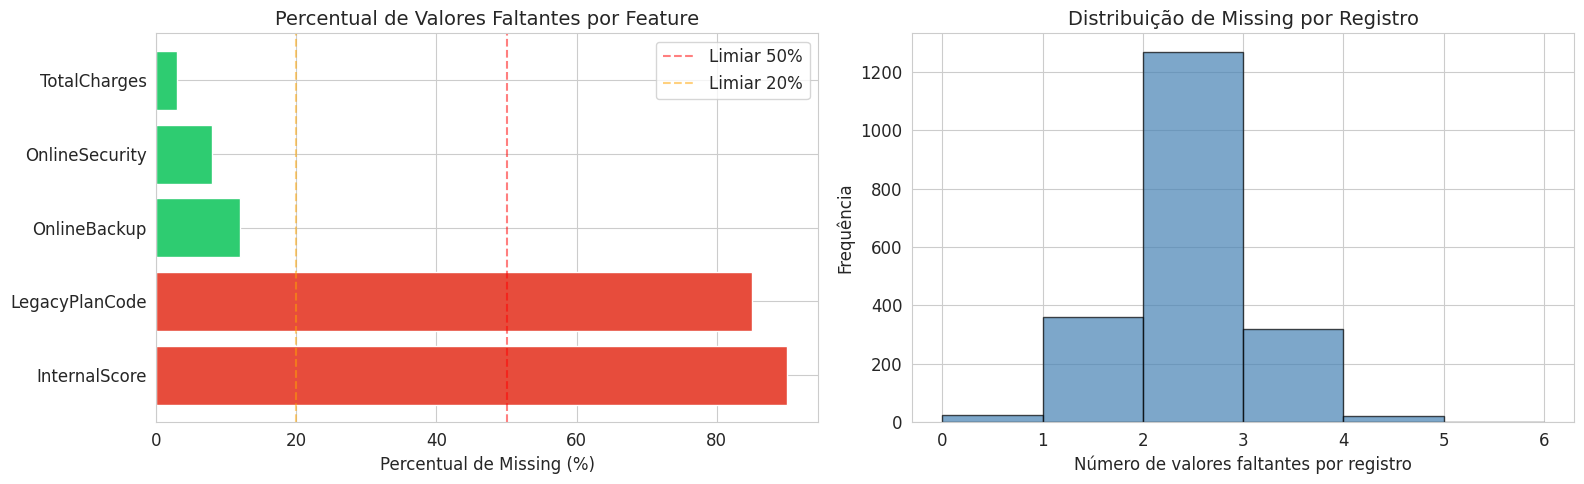

In [ ]:
# Visualização dos missing values
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de barras dos missing
missing_cols = missing_df.index.tolist()
colors = ['#e74c3c' if pct > 50 else '#f39c12' if pct > 20 else '#2ecc71'
          for pct in missing_df['Percentual (%)']]
axes[0].barh(missing_cols, missing_df['Percentual (%)'], color=colors)
axes[0].set_xlabel('Percentual de Missing (%)')
axes[0].set_title('Percentual de Valores Faltantes por Feature')
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Limiar 50%')
axes[0].axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='Limiar 20%')
axes[0].legend()

# Distribuição de missing por amostra
missing_per_row = df.isnull().sum(axis=1)
axes[1].hist(missing_per_row, bins=range(0, missing_per_row.max() + 2),
             color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Número de valores faltantes por registro')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição de Missing por Registro')

plt.tight_layout()
plt.show()


---
## 4. Técnica 1: Tratamento de Dados Faltantes como Redução de Dimensionalidade

### Conceito

Quando uma feature possui um percentual muito alto de valores faltantes, ela traz **pouca informação** e pode ser mais prejudicial do que útil. A decisão de remover ou manter envolve:

| % Missing | Ação Recomendada |
|-----------|-----------------|
| 0 - 5% | Imputação (média, mediana, moda, KNN) |
| 5 - 30% | Imputação cuidadosa + análise de padrão (MCAR, MAR, MNAR) |
| 30 - 50% | Avaliar custo-benefício; considerar remoção |
| > 50% | Forte candidata à remoção |

### Mecanismos de Missing Data

- **MCAR** (Missing Completely At Random): ausência não depende de nenhuma variável
- **MAR** (Missing At Random): ausência depende de outras variáveis observadas
- **MNAR** (Missing Not At Random): ausência depende do próprio valor que falta

> **⚠️ Importante:** Remover features com muitos missings é uma forma de reduzir dimensionalidade, mas devemos documentar o motivo e verificar se não estamos perdendo informação valiosa.


In [ ]:
# Análise de missing values para decisão de remoção
print("=" * 70)
print("ANÁLISE DE DADOS FALTANTES PARA REDUÇÃO DE DIMENSIONALIDADE")
print("=" * 70)

threshold_remove = 50  # Remover features com mais de 50% missing
threshold_impute = 20  # Imputar features com até 20% missing

all_cols = df.columns.tolist()
missing_analysis = pd.DataFrame({
    'Feature': all_cols,
    'Missing_Count': [df[c].isnull().sum() for c in all_cols],
    'Missing_Pct': [(df[c].isnull().sum() / len(df) * 100) for c in all_cols],
    'Dtype': [str(df[c].dtype) for c in all_cols]
})
missing_analysis = missing_analysis.sort_values('Missing_Pct', ascending=False)

# Classificar ação
def classify_action(pct):
    if pct > threshold_remove:
        return '🔴 REMOVER'
    elif pct > threshold_impute:
        return '🟡 AVALIAR'
    elif pct > 0:
        return '🟢 IMPUTAR'
    else:
        return '✅ OK'

missing_analysis['Ação'] = missing_analysis['Missing_Pct'].apply(classify_action)
print(missing_analysis[missing_analysis['Missing_Count'] > 0].to_string(index=False))

# Aplicar remoção
cols_to_remove_missing = missing_analysis[
    missing_analysis['Missing_Pct'] > threshold_remove
]['Feature'].tolist()

print(f"\n📌 Features removidas por excesso de missing (>{threshold_remove}%): {cols_to_remove_missing}")

df_clean = df.drop(columns=cols_to_remove_missing)



ANÁLISE DE DADOS FALTANTES PARA REDUÇÃO DE DIMENSIONALIDADE
       Feature  Missing_Count  Missing_Pct   Dtype      Ação
 InternalScore           1800         90.0 float64 🔴 REMOVER
LegacyPlanCode           1700         85.0  object 🔴 REMOVER
  OnlineBackup            240         12.0  object 🟢 IMPUTAR
OnlineSecurity            160          8.0  object 🟢 IMPUTAR
  TotalCharges             60          3.0 float64 🟢 IMPUTAR

📌 Features removidas por excesso de missing (>50%): ['InternalScore', 'LegacyPlanCode']


In [ ]:
df['TotalCharges'].unique()

array([  51.44,  377.76, 2433.84, ..., 3622.67,  149.28, 5936.57])

In [ ]:
# Imputar os demais
for col in df_clean.columns:
    if df_clean[col].isnull().any():
        if df_clean[col].dtype in ['float64', 'int64']:
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
            print(f"  ✔ {col}: imputado com mediana ({median_val:.2f})")
        else:
            mode_val = df_clean[col].mode()[0]
            df_clean[col] = df_clean[col].fillna(mode_val)
            print(f"  ✔ {col}: imputado com moda ('{mode_val}')")

print(f"\n✅ Dataset após tratamento de missing: {df_clean.shape[1]} colunas (removidas {len(cols_to_remove_missing)})")
print(f"   Missing restantes: {df_clean.isnull().sum().sum()}")


  ✔ OnlineSecurity: imputado com moda ('No')
  ✔ OnlineBackup: imputado com moda ('No')
  ✔ TotalCharges: imputado com mediana (964.47)

✅ Dataset após tratamento de missing: 27 colunas (removidas 2)
   Missing restantes: 0


---
## 5. Técnica 2: Remoção de Features com Baixa Variabilidade

### Conceito

Uma feature que tem **variância próxima de zero** (ou que assume praticamente um único valor) não contribui para a discriminação entre classes. Exemplos comuns:

- Colunas constantes (ex.: `Country = 'Brazil'` para todos)
- Colunas quase-constantes (ex.: `PromoCode2019` onde 99.5% é 0)
- IDs e identificadores únicos

### Critérios de remoção

- **Variância zero:** feature constante → remover sempre
- **Quase-constante:** quando um único valor representa mais de 95-99% dos registros
- **VarianceThreshold** do scikit-learn: remove features cuja variância está abaixo de um limiar

### Cuidados

- Features binárias raras podem ser importantes (ex.: fraude em 0.1% dos casos)
- Sempre considerar o **contexto de negócio** antes de remover


In [ ]:
df['TotalCharges'].value_counts(normalize=True)

,proportion
TotalCharges,
0.00,0.018041
376.51,0.001031
1583.43,0.001031
549.61,0.001031
1161.45,0.001031
...,...
1593.42,0.000515
2550.40,0.000515
1660.04,0.000515


In [ ]:
vc = df['TotalCharges'].value_counts(normalize=True)
vc.iloc[0] * 100

np.float64(1.804123711340206)

In [ ]:
dominant_pct = vc.iloc[0] * 100
n_unique = df_work[col].nunique()
status = '🔴 REMOVER' if dominant_pct >= 99 else ('🟡 ATENÇÃO' if dominant_pct >= 95 else '✅ OK')
print(f"  {col:25s} | Valores únicos: {n_unique:3d} | Dominante: {vc.index[0]:25s} ({dominant_pct:.1f}%) | {status}")
if dominant_pct >= 99:
    low_var_cat.append(col)

In [ ]:
from sklearn.feature_selection import VarianceThreshold

print("=" * 70)
print("ANÁLISE DE BAIXA VARIABILIDADE")
print("=" * 70)

# Remover customerID (identificador, não é feature)
df_work = df_clean.drop(columns=['customerID'])

# Analisar variabilidade de colunas categóricas
print("\n--- Features Categóricas ---")
cat_cols = df_work.select_dtypes(include='object').columns.tolist()
low_var_cat = []

for col in cat_cols:
    vc = df_work[col].value_counts(normalize=True)
    dominant_pct = vc.iloc[0] * 100
    n_unique = df_work[col].nunique()
    status = '🔴 REMOVER' if dominant_pct >= 99 else ('🟡 ATENÇÃO' if dominant_pct >= 95 else '✅ OK')
    print(f"  {col:25s} | Valores únicos: {n_unique:3d} | Dominante: {vc.index[0]:25s} ({dominant_pct:.1f}%) | {status}")
    if dominant_pct >= 99:
        low_var_cat.append(col)

# Analisar variabilidade de colunas numéricas
print("\n--- Features Numéricas ---")
num_cols = df_work.select_dtypes(include=[np.number]).columns.tolist()
low_var_num = []

for col in num_cols:
    var = df_work[col].var()
    n_unique = df_work[col].nunique()
    dominant_pct = df_work[col].value_counts(normalize=True).iloc[0] * 100
    status = '🔴 REMOVER' if n_unique <= 1 or dominant_pct >= 99 else '✅ OK'
    print(f"  {col:25s} | Variância: {var:12.4f} | Únicos: {n_unique:5d} | Dominante: {dominant_pct:.1f}% | {status}")
    if n_unique <= 1 or dominant_pct >= 99:
        low_var_num.append(col)

cols_to_remove_var = low_var_cat + low_var_num
print(f"\n📌 Features removidas por baixa variabilidade: {cols_to_remove_var}")

df_work = df_work.drop(columns=cols_to_remove_var)
print(f"✅ Dataset após remoção: {df_work.shape[1]} colunas (removidas {len(cols_to_remove_var)})")


ANÁLISE DE BAIXA VARIABILIDADE

--- Features Categóricas ---
  gender                    | Valores únicos:   2 | Dominante: Male                      (50.8%) | ✅ OK
  Partner                   | Valores únicos:   2 | Dominante: No                        (50.8%) | ✅ OK
  Dependents                | Valores únicos:   2 | Dominante: No                        (69.8%) | ✅ OK
  PhoneService              | Valores únicos:   2 | Dominante: Yes                       (89.9%) | ✅ OK
  MultipleLines             | Valores únicos:   3 | Dominante: No                        (54.5%) | ✅ OK
  InternetService           | Valores únicos:   3 | Dominante: Fiber optic               (44.0%) | ✅ OK
  OnlineSecurity            | Valores únicos:   3 | Dominante: No                        (54.8%) | ✅ OK
  OnlineBackup              | Valores únicos:   3 | Dominante: No                        (55.0%) | ✅ OK
  TechSupport               | Valores únicos:   3 | Dominante: No                        (49.9%) | ✅ OK
  S

### Preparação: Encoding de Variáveis Categóricas

Para as próximas técnicas (multicolinearidade, PCA, LDA, t-SNE) precisamos de dados numéricos. Vamos aplicar Label Encoding e One-Hot Encoding conforme apropriado.


In [ ]:
# Separar target
target = df_work['Churn'].map({'Yes': 1, 'No': 0})
df_features = df_work.drop(columns=['Churn'])

# Identificar colunas categóricas restantes
cat_cols = df_features.select_dtypes(include='object').columns.tolist()
num_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()

print(f"Features categóricas para encoding: {cat_cols}")
print(f"Features numéricas: {num_cols}")

# One-Hot Encoding para categóricas
df_encoded = pd.get_dummies(df_features, columns=cat_cols, drop_first=True, dtype=int)

print(f"\n✅ Dataset após encoding: {df_encoded.shape[0]} linhas x {df_encoded.shape[1]} colunas")
print(f"   Colunas: {list(df_encoded.columns)}")


Features categóricas para encoding: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Features numéricas: ['SeniorCitizen', 'tenure', 'tenure_months', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge', 'ChargesRatio']

✅ Dataset após encoding: 2000 linhas x 31 colunas
   Colunas: ['SeniorCitizen', 'tenure', 'tenure_months', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge', 'ChargesRatio', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet se

---
## 6. Técnica 3: Remoção por

 Multicolinearidade

### Conceito

**Multicolinearidade** ocorre quando duas ou mais features são altamente correlacionadas entre si. Isso causa problemas como:

- **Instabilidade nos coeficientes** de modelos lineares (regressão, LDA)
- **Redundância de informação**: se `MonthlyCharges` e `AvgMonthlyCharge` carregam a mesma informação, manter ambas é desperdício
- **Inflação da variância** dos estimadores (alto VIF — *Variance Inflation Factor*)

### Métodos de Detecção

1. **Matriz de Correlação de Pearson**: identifica correlações lineares bivariadas
2. **VIF (Variance Inflation Factor)**: detecta multicolinearidade multivariada
   - VIF > 5 → preocupante
   - VIF > 10 → deve ser tratado
   

### Abordagem Prática

1. Calcular a matriz de correlação
2. Identificar pares com |correlação| > 0.85
3. Remover a feature com menor correlação com o target


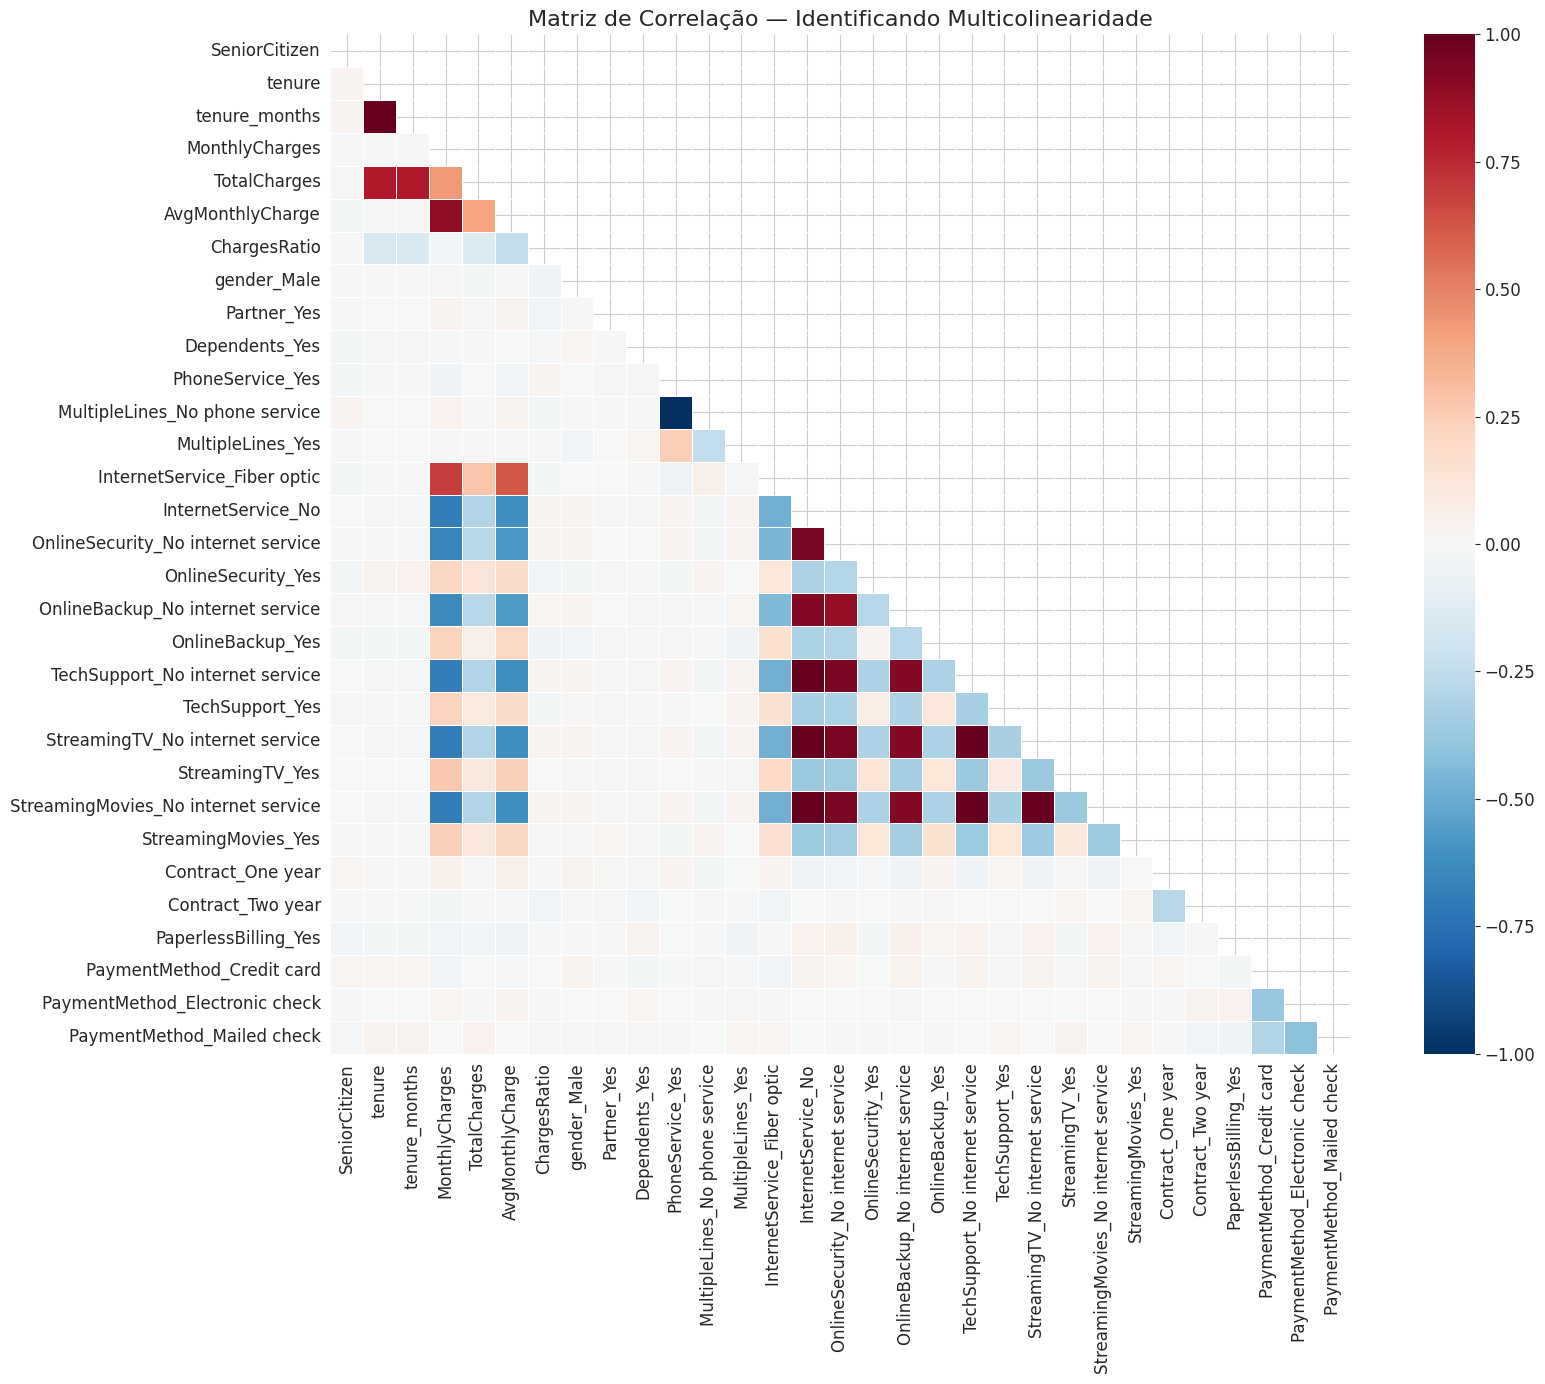

In [ ]:
# Matriz de correlação completa
corr_matrix = df_encoded.corr()

# Visualização da matriz de correlação
fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlação — Identificando Multicolinearidade', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# Identificar pares altamente correlacionados
threshold_corr = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > threshold_corr:
            high_corr_pairs.append({
                'Feature_1': col_i,
                'Feature_2': col_j,
                'Correlação': round(corr_val, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlação', key=abs, ascending=False)

print("=" * 70)
print(f"PARES COM |CORRELAÇÃO| > {threshold_corr}")
print("=" * 70)
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))
else:
    print("Nenhum par encontrado acima do limiar.")


PARES COM |CORRELAÇÃO| > 0.85
                         Feature_1                           Feature_2  Correlação
                InternetService_No     TechSupport_No internet service      1.0000
                  PhoneService_Yes      MultipleLines_No phone service     -1.0000
   StreamingTV_No internet service StreamingMovies_No internet service      1.0000
   TechSupport_No internet service     StreamingTV_No internet service      1.0000
                InternetService_No StreamingMovies_No internet service      1.0000
                InternetService_No     StreamingTV_No internet service      1.0000
   TechSupport_No internet service StreamingMovies_No internet service      1.0000
                            tenure                       tenure_months      0.9997
OnlineSecurity_No internet service StreamingMovies_No internet service      0.9503
OnlineSecurity_No internet service     TechSupport_No internet service      0.9503
                InternetService_No  OnlineSecurity_No int

In [ ]:
# Remover features multicolineares de forma iterativa
# Estratégia: para cada par, remover a feature com menor correlação absoluta com o target

# Correlação de cada feature com o target
target_corr = df_encoded.corrwith(target).abs()

cols_to_remove_multi = set()
for _, row in high_corr_df.iterrows():
    f1, f2 = row['Feature_1'], row['Feature_2']
    # Se ambas ainda não foram marcadas para remoção
    if f1 not in cols_to_remove_multi and f2 not in cols_to_remove_multi:
        # Manter a que tem maior correlação com o target
        corr_f1 = target_corr.get(f1, 0)
        corr_f2 = target_corr.get(f2, 0)
        to_remove = f2 if corr_f1 >= corr_f2 else f1
        cols_to_remove_multi.add(to_remove)
        print(f"  🔄 Par ({f1}, {f2}): removendo '{to_remove}' "
              f"(corr com target: {target_corr.get(to_remove, 0):.4f} vs "
              f"{target_corr.get(f1 if to_remove == f2 else f2, 0):.4f})")

cols_to_remove_multi = list(cols_to_remove_multi)
print(f"\n📌 Features removidas por multicolinearidade: {cols_to_remove_multi}")

df_reduced = df_encoded.drop(columns=cols_to_remove_multi)
print(f"✅ Dataset após remoção: {df_reduced.shape[1]} colunas (removidas {len(cols_to_remove_multi)})")


  🔄 Par (InternetService_No, TechSupport_No internet service): removendo 'TechSupport_No internet service' (corr com target: 0.1163 vs 0.1163)
  🔄 Par (PhoneService_Yes, MultipleLines_No phone service): removendo 'MultipleLines_No phone service' (corr com target: 0.0167 vs 0.0167)
  🔄 Par (StreamingTV_No internet service, StreamingMovies_No internet service): removendo 'StreamingMovies_No internet service' (corr com target: 0.1163 vs 0.1163)
  🔄 Par (InternetService_No, StreamingTV_No internet service): removendo 'StreamingTV_No internet service' (corr com target: 0.1163 vs 0.1163)
  🔄 Par (tenure, tenure_months): removendo 'tenure' (corr com target: 0.1882 vs 0.1883)
  🔄 Par (InternetService_No, OnlineSecurity_No internet service): removendo 'InternetService_No' (corr com target: 0.1163 vs 0.1195)
  🔄 Par (MonthlyCharges, AvgMonthlyCharge): removendo 'AvgMonthlyCharge' (corr com target: 0.1833 vs 0.2233)
  🔄 Par (OnlineSecurity_No internet service, OnlineBackup_No internet service): r

In [ ]:
# VIF (Variance Inflation Factor) — validação da remoção
from numpy.linalg import LinAlgError

def calculate_vif(X):
    """Calcula VIF para cada feature usando a definição: VIF_j = 1 / (1 - R²_j)"""
    vif_data = []
    X_arr = X.values.astype(float)
    for i in range(X_arr.shape[1]):
        y_i = X_arr[:, i]
        X_i = np.delete(X_arr, i, axis=1)
        # Adicionar intercepto
        X_i = np.column_stack([np.ones(X_i.shape[0]), X_i])
        try:
            # R² via OLS
            beta = np.linalg.lstsq(X_i, y_i, rcond=None)[0]
            y_pred = X_i @ beta
            ss_res = np.sum((y_i - y_pred) ** 2)
            ss_tot = np.sum((y_i - y_i.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            vif = 1 / (1 - r2) if r2 < 1 else float('inf')
        except LinAlgError:
            vif = float('inf')
        vif_data.append({'Feature': X.columns[i], 'VIF': round(vif, 2)})
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)



In [ ]:

# Calcular VIF apenas para numéricas contínuas (excluir dummies binárias para eficiência)
continuous_cols = [c for c in df_reduced.columns
                   if df_reduced[c].nunique() > 10]

if len(continuous_cols) > 0:
    vif_result = calculate_vif(df_reduced[continuous_cols])
    print("VIF das features contínuas após remoção:")
    print(vif_result.to_string(index=False))
    print("\n(VIF > 5 = preocupante | VIF > 10 = crítico)")

VIF das features contínuas após remoção:
       Feature  VIF
  TotalCharges 5.89
 tenure_months 4.83
MonthlyCharges 2.08
  ChargesRatio 1.03

(VIF > 5 = preocupante | VIF > 10 = crítico)


---
## 7. Resumo da Redução por Filtragem

Antes de aplicar as técnicas de transformação (PCA, LDA, t-SNE), vamos resumir o que foi feito:


In [ ]:
print("=" * 70)
print("RESUMO DA REDUÇÃO POR FILTRAGEM")
print("=" * 70)
print(f"\n  Dataset original:              {df.shape[1]} colunas")
print(f"  Após remoção de ID:            {df.shape[1] - 1} colunas")
print(f"  Removidas por missing (>50%):  {len(cols_to_remove_missing)} colunas → {cols_to_remove_missing}")
print(f"  Removidas por baixa variância: {len(cols_to_remove_var)} colunas → {cols_to_remove_var}")
print(f"  Após one-hot encoding:         {df_encoded.shape[1]} colunas")
print(f"  Removidas por multicolinear.:  {len(cols_to_remove_multi)} colunas → {cols_to_remove_multi}")
print(f"  ─────────────────────────────────────────────")
print(f"  Dataset final para PCA/LDA:    {df_reduced.shape[1]} colunas")
print(f"  Total de registros:            {df_reduced.shape[0]}")


RESUMO DA REDUÇÃO POR FILTRAGEM

  Dataset original:              29 colunas
  Após remoção de ID:            28 colunas
  Removidas por missing (>50%):  2 colunas → ['InternalScore', 'LegacyPlanCode']
  Removidas por baixa variância: 4 colunas → ['Country', 'Currency', 'ActiveService', 'PromoCode2019']
  Após one-hot encoding:         31 colunas
  Removidas por multicolinear.:  8 colunas → ['TechSupport_No internet service', 'InternetService_No', 'OnlineBackup_No internet service', 'StreamingMovies_No internet service', 'tenure', 'AvgMonthlyCharge', 'StreamingTV_No internet service', 'MultipleLines_No phone service']
  ─────────────────────────────────────────────
  Dataset final para PCA/LDA:    23 colunas
  Total de registros:            2000


### Padronização (StandardScaler)

PCA e LDA são sensíveis à escala dos dados. Precisamos padronizar (média=0, desvio=1) **antes** de aplicar essas técnicas.


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_reduced)
X_scaled = pd.DataFrame(X_scaled, columns=df_reduced.columns)

y = target.values

print(f"Dados padronizados: {X_scaled.shape}")
print(f"\nVerificação (primeiras 3 features):")
for col in X_scaled.columns[:3]:
    print(f"  {col:25s} → média: {X_scaled[col].mean():.6f}, desvio: {X_scaled[col].std():.4f}")


Dados padronizados: (2000, 23)

Verificação (primeiras 3 features):
  SeniorCitizen             → média: 0.000000, desvio: 1.0003
  tenure_months             → média: -0.000000, desvio: 1.0003
  MonthlyCharges            → média: -0.000000, desvio: 1.0003


---
## 8. Técnica 4: PCA — Principal Component Analysis

### Conceito

O PCA é uma técnica de **transformação linear não-supervisionada** que busca novas direções (componentes principais) no espaço de features que **maximizam a variância** dos dados.

### Como funciona (passo a passo)

1. **Padronizar** os dados (média 0, variância 1)
2. Calcular a **matriz de covariância**
3. Calcular os **autovalores** e **autovetores** da matriz de covariância
4. **Ordenar** os autovetores pelo autovalor (maior → menor variância explicada)
5. **Selecionar** os k primeiros componentes
6. **Projetar** os dados no novo espaço k-dimensional

### Propriedades

- Os componentes são **ortogonais** entre si (não correlacionados)
- PC1 captura a maior variância, PC2 a segunda maior, e assim por diante
- É uma **transformação linear** → não captura relações não-lineares
- **Não supervisionado** → ignora as classes/labels

### Critérios para escolher o número de componentes

- **Variância acumulada** ≥ 85-95%
- **Regra do cotovelo** (Scree Plot)
- **Critério de Kaiser**: manter componentes com autovalor > 1


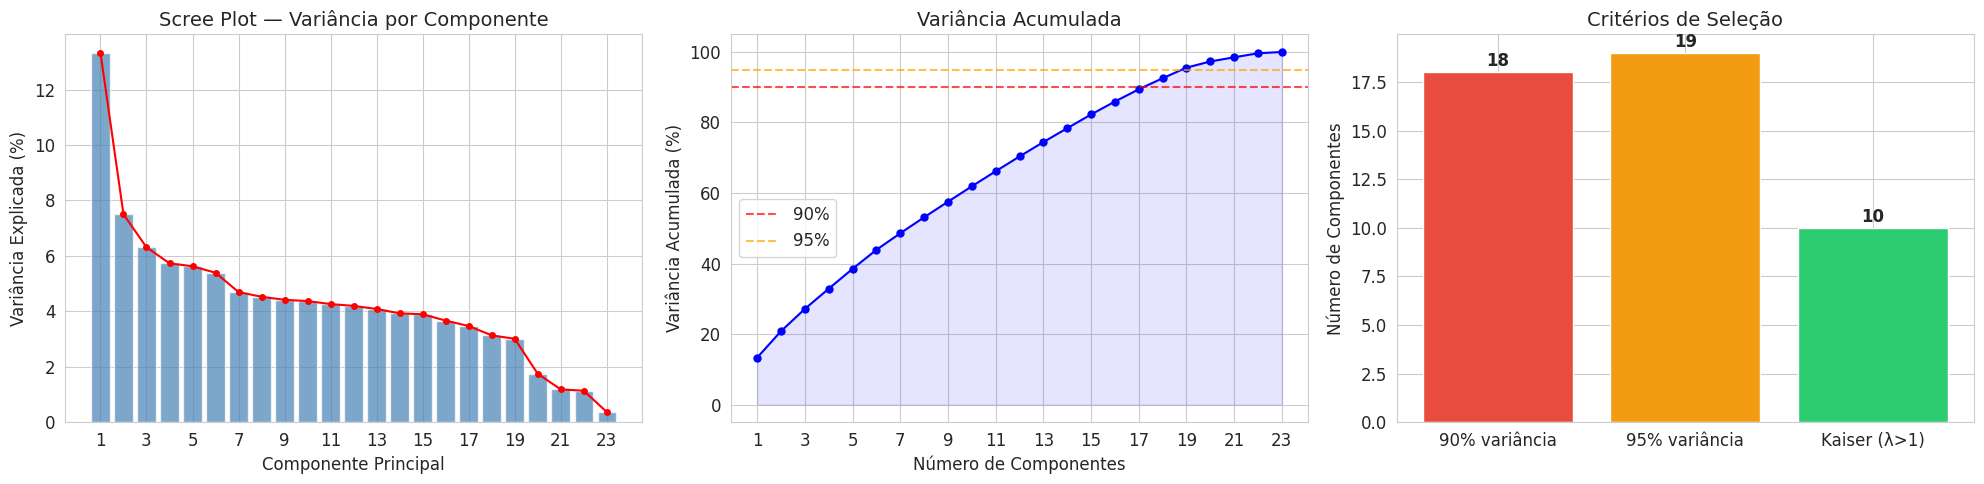


📊 Resultados:
  Componentes para 90% da variância: 18 (de 23 originais)
  Componentes para 95% da variância: 19
  Critério de Kaiser (autovalor > 1): 10 componentes


In [ ]:
# Aplicar PCA com todos os componentes para análise
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Variância explicada
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Scree Plot
axes[0].bar(range(1, len(explained_var) + 1), explained_var * 100,
            color='steelblue', alpha=0.7, label='Individual')
axes[0].plot(range(1, len(explained_var) + 1), explained_var * 100,
             'ro-', markersize=4)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada (%)')
axes[0].set_title('Scree Plot — Variância por Componente')
axes[0].set_xticks(range(1, len(explained_var) + 1, 2))

# Variância acumulada
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var * 100,
             'b-o', markersize=5)
axes[1].axhline(y=90, color='r', linestyle='--', alpha=0.7, label='90%')
axes[1].axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95%')
axes[1].fill_between(range(1, len(cumulative_var) + 1), cumulative_var * 100,
                      alpha=0.1, color='blue')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Acumulada (%)')
axes[1].set_title('Variância Acumulada')
axes[1].legend()
axes[1].set_xticks(range(1, len(explained_var) + 1, 2))

# Encontrar número ótimo de componentes
n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1
kaiser = np.sum(pca_full.explained_variance_ > 1)

# Comparativo
criteria = {'90% variância': n_90, '95% variância': n_95, 'Kaiser (λ>1)': kaiser}
bars = axes[2].bar(criteria.keys(), criteria.values(),
                    color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[2].set_ylabel('Número de Componentes')
axes[2].set_title('Critérios de Seleção')
for bar, val in zip(bars, criteria.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Resultados:")
print(f"  Componentes para 90% da variância: {n_90} (de {X_scaled.shape[1]} originais)")
print(f"  Componentes para 95% da variância: {n_95}")
print(f"  Critério de Kaiser (autovalor > 1): {kaiser} componentes")


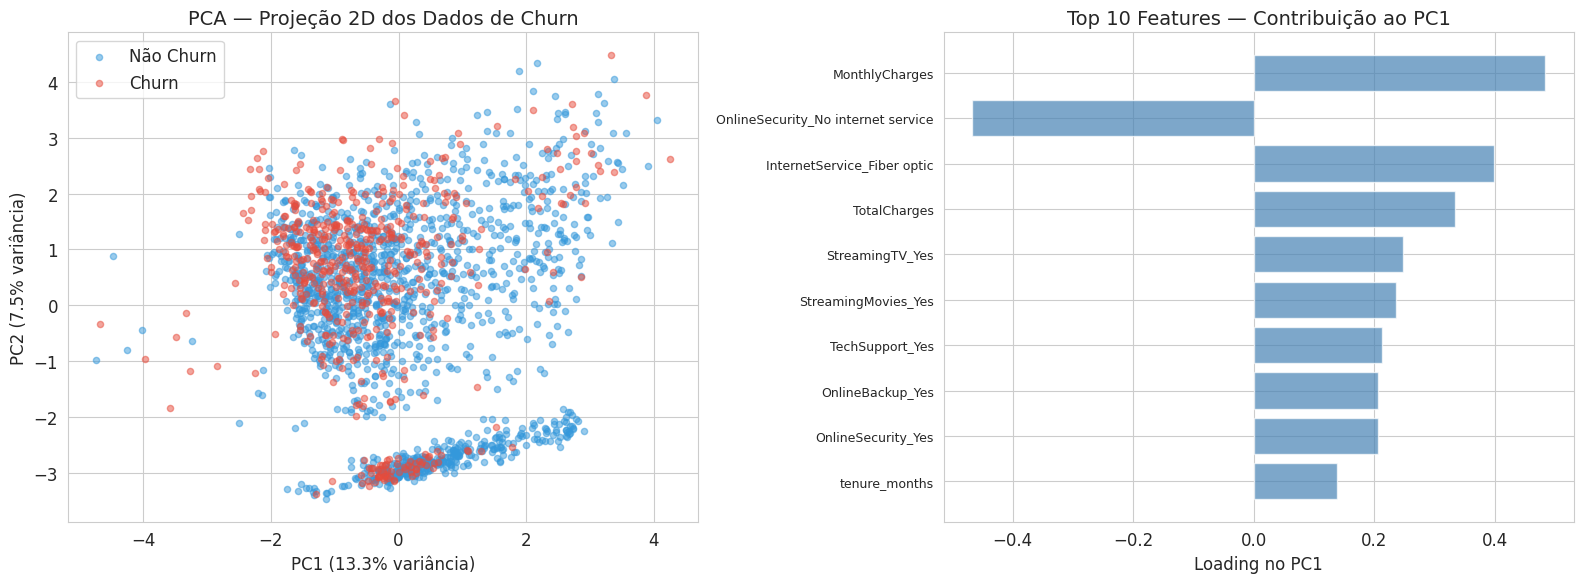


Variância total explicada por 2 componentes: 20.8%


In [ ]:
# PCA com 2 componentes para visualização
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot com classes
colors = {0: '#3498db', 1: '#e74c3c'}
labels = {0: 'Não Churn', 1: 'Churn'}

for cls in [0, 1]:
    mask = y == cls
    axes[0].scatter(X_pca_2d[mask, 1], X_pca_2d[mask, 0],
                    c=colors[cls], label=labels[cls], alpha=0.5, s=20)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variância)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variância)')
axes[0].set_title('PCA — Projeção 2D dos Dados de Churn')
axes[0].legend()

# Loadings (contribuição das features originais)
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=df_reduced.columns
)
top_loadings = loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index)[:10]

axes[1].barh(range(len(top_loadings)), top_loadings['PC1'], color='steelblue', alpha=0.7)
axes[1].set_yticks(range(len(top_loadings)))
axes[1].set_yticklabels(top_loadings.index, fontsize=9)
axes[1].set_xlabel('Loading no PC1')
axes[1].set_title('Top 10 Features — Contribuição ao PC1')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nVariância total explicada por 2 componentes: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")


---
## 9. Técnica 5: LDA — Linear Discriminant Analysis

### Conceito

Enquanto o PCA busca **maximizar a variância** (não supervisionado), o LDA busca **maximizar a separação entre classes** (supervisionado).

### Diferença fundamental: PCA vs LDA

| Aspecto | PCA | LDA |
|---------|-----|-----|
| Tipo | Não-supervisionado | Supervisionado |
| Objetivo | Maximizar variância total | Maximizar separação entre classes |
| Usa labels? | Não | Sim |
| Max componentes | min(n_features, n_samples) | min(n_features, n_classes - 1) |
| Melhor para | Visualização, compressão | Classificação |

### Como funciona

1. Calcular a **média** de cada classe
2. Calcular a **matriz de dispersão intra-classe** (Sw) — variância dentro das classes
3. Calcular a **matriz de dispersão inter-classe** (Sb) — variância entre as classes
4. Resolver o problema de autovalores para **Sw⁻¹ · Sb**
5. Projetar nos autovetores com maiores autovalores

### Limitação importante

Para um problema binário (2 classes), o LDA gera **no máximo 1 componente** (n_classes - 1 = 1).


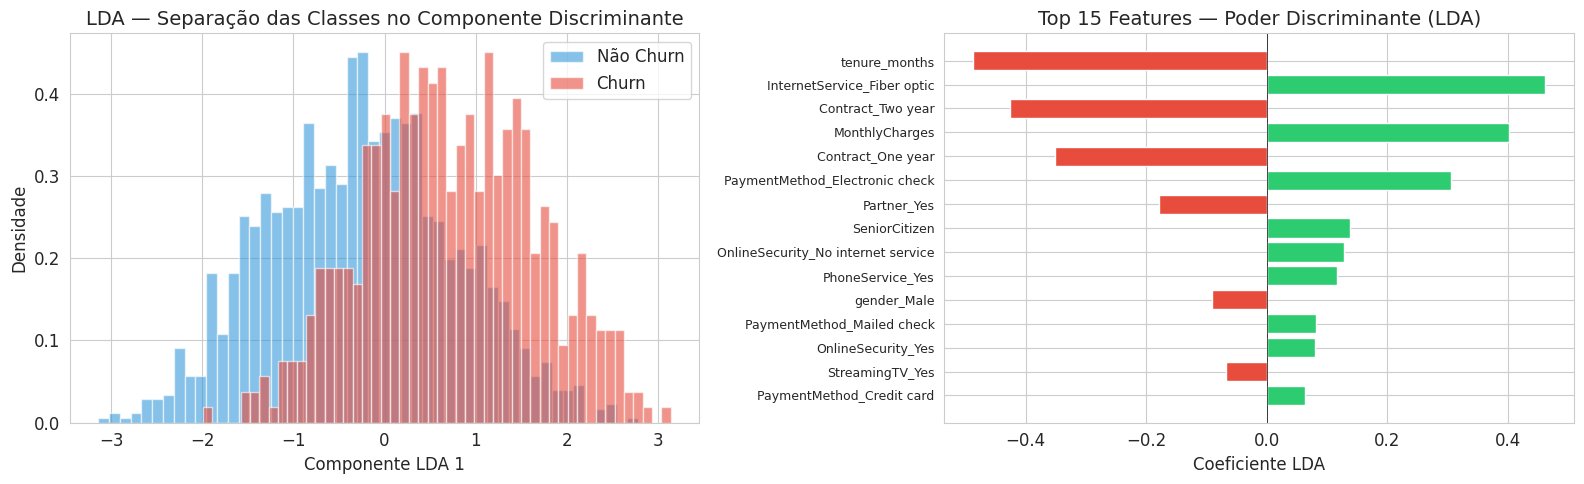


📊 Separação LDA:
  Média Não-Churn: -0.2522
  Média Churn:     0.7196
  Razão de variância explicada: 100.0%


In [ ]:
# LDA — como temos 2 classes (Churn/Não Churn), teremos 1 componente
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribuição das classes no eixo LDA
for cls in [0, 1]:
    mask = y == cls
    axes[0].hist(X_lda[mask], bins=50, alpha=0.6, color=colors[cls],
                 label=labels[cls], density=True)
axes[0].set_xlabel('Componente LDA 1')
axes[0].set_ylabel('Densidade')
axes[0].set_title('LDA — Separação das Classes no Componente Discriminante')
axes[0].legend()

# Coeficientes do LDA (importância das features)
lda_coefs = pd.Series(lda.coef_[0], index=df_reduced.columns)
top_lda = lda_coefs.abs().sort_values(ascending=False)[:15]

axes[1].barh(range(len(top_lda)), lda_coefs[top_lda.index],
             color=['#e74c3c' if v < 0 else '#2ecc71' for v in lda_coefs[top_lda.index]])
axes[1].set_yticks(range(len(top_lda)))
axes[1].set_yticklabels(top_lda.index, fontsize=9)
axes[1].set_xlabel('Coeficiente LDA')
axes[1].set_title('Top 15 Features — Poder Discriminante (LDA)')
axes[1].invert_yaxis()
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"\n📊 Separação LDA:")
print(f"  Média Não-Churn: {X_lda[y == 0].mean():.4f}")
print(f"  Média Churn:     {X_lda[y == 1].mean():.4f}")
print(f"  Razão de variância explicada: {lda.explained_variance_ratio_[0]*100:.1f}%")


### Comparação Visual: PCA vs LDA

Vamos comparar a capacidade de separação das classes usando PCA (1 componente) vs LDA (1 componente).


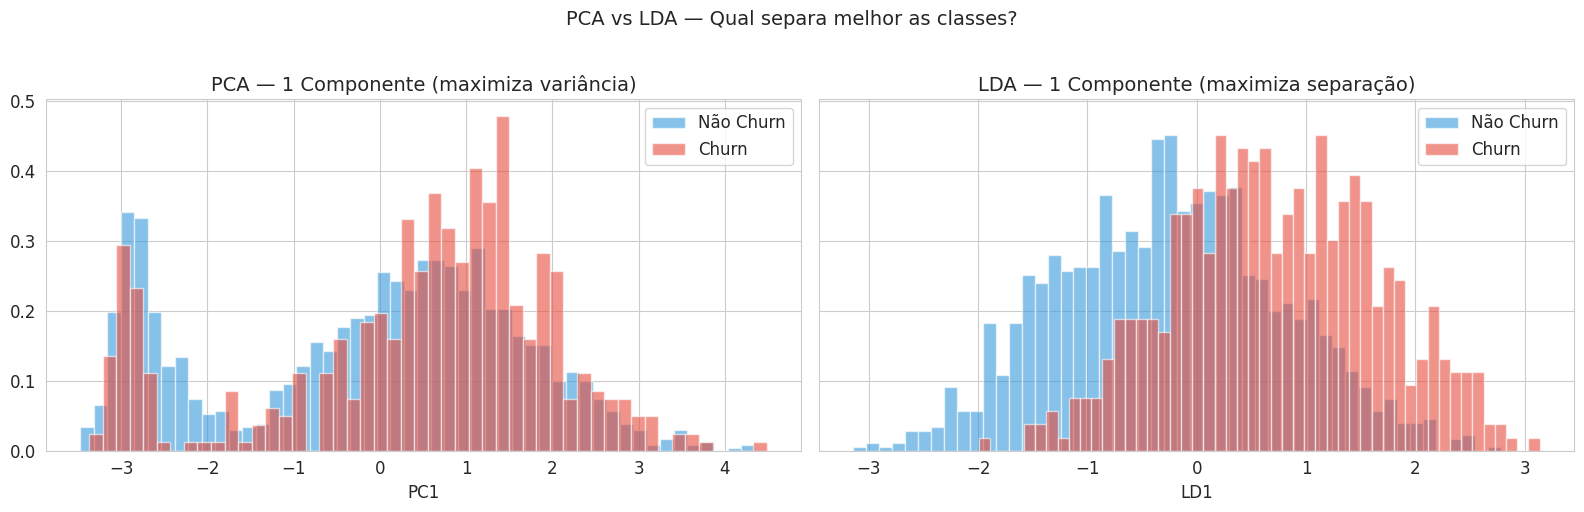

Observe como o LDA (direita) tende a criar uma separação mais clara entre as classes,
pois usa a informação dos labels para encontrar a melhor projeção discriminante.


In [ ]:
# Comparação PCA 1D vs LDA 1D
pca_1d = PCA(n_components=1)
X_pca_1d = pca_1d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# PCA 1D
for cls in [0, 1]:
    mask = y == cls
    axes[0].hist(X_pca_1d[mask], bins=50, alpha=0.6, color=colors[cls],
                 label=labels[cls], density=True)
axes[0].set_xlabel('PC1')
axes[0].set_title('PCA — 1 Componente (maximiza variância)')
axes[0].legend()

# LDA 1D
for cls in [0, 1]:
    mask = y == cls
    axes[1].hist(X_lda[mask], bins=50, alpha=0.6, color=colors[cls],
                 label=labels[cls], density=True)
axes[1].set_xlabel('LD1')
axes[1].set_title('LDA — 1 Componente (maximiza separação)')
axes[1].legend()

plt.suptitle('PCA vs LDA — Qual separa melhor as classes?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Observe como o LDA (direita) tende a criar uma separação mais clara entre as classes,")
print("pois usa a informação dos labels para encontrar a melhor projeção discriminante.")


---
## 10. Técnica 6: t-SNE — T-Distributed Stochastic Neighbour Embedding

### Conceito

O t-SNE é uma técnica de redução **não-linear** focada em **visualização** em 2D ou 3D. Diferente do PCA (linear), o t-SNE preserva a **estrutura local** dos dados — pontos que são vizinhos no espaço original tendem a ficar próximos na projeção.

### Como funciona

1. Calcula a **similaridade** (probabilidade condicional) entre cada par de pontos no espaço original usando uma distribuição Gaussiana
2. Define uma distribuição de **t-Student** no espaço de baixa dimensão
3. **Minimiza a divergência KL** entre as duas distribuições, iterativamente ajustando as posições no espaço reduzido

### Hiperparâmetro: Perplexidade

A **perplexidade** controla o equilíbrio entre atenção à estrutura local vs global:

| Perplexidade | Comportamento |
|-------------|--------------|
| Baixa (5-10) | Clusters menores, mais fragmentados |
| Média (30-50) | Bom equilíbrio geral |
| Alta (100+) | Clusters maiores, mais "difusos" |

### Cuidados importantes

- t-SNE **não preserva distâncias globais** — o tamanho e a distância entre clusters não são significativos
- É **não-determinístico** — cada execução pode gerar um resultado diferente (use `random_state`)
- **Não pode ser usado para transformar novos dados** (não há `.transform()`)
- É **computacionalmente custoso** para datasets grandes
- Ideal para **visualização**, não para alimentar modelos de ML


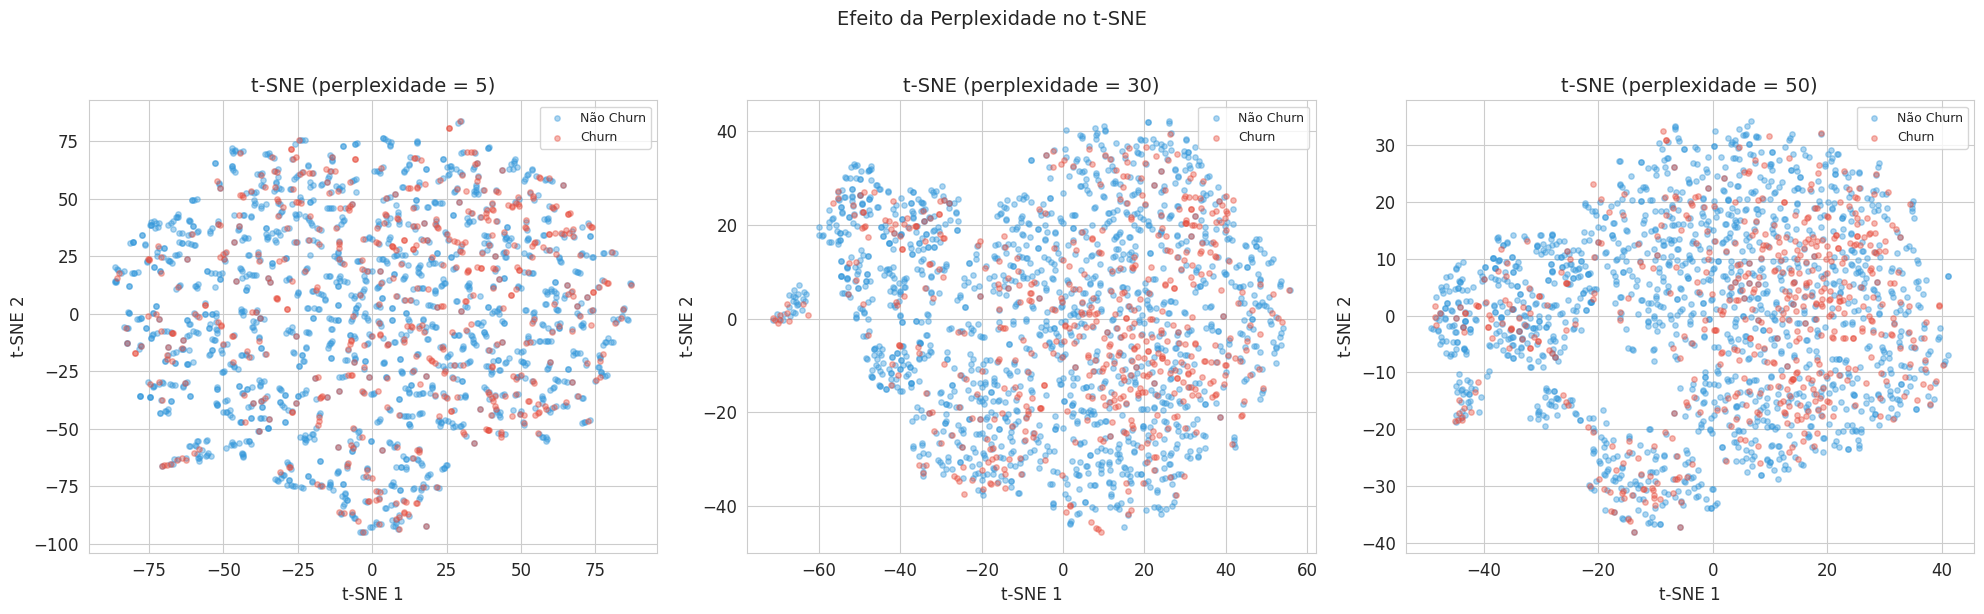


📌 Observações:
  • Perplexidade baixa (5): fragmenta os dados em micro-clusters
  • Perplexidade média (30): bom equilíbrio entre local e global
  • Perplexidade alta (50): clusters mais suaves e conectados


In [ ]:
# t-SNE com diferentes perplexidades
perplexities = [5, 30, 50]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                max_iter=1000, learning_rate='auto', init='pca')
    X_tsne = tsne.fit_transform(X_scaled)

    for cls in [0, 1]:
        mask = y == cls
        axes[idx].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                         c=colors[cls], label=labels[cls], alpha=0.4, s=15)

    axes[idx].set_title(f't-SNE (perplexidade = {perp})')
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].legend(fontsize=9)

plt.suptitle('Efeito da Perplexidade no t-SNE', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 Observações:")
print("  • Perplexidade baixa (5): fragmenta os dados em micro-clusters")
print("  • Perplexidade média (30): bom equilíbrio entre local e global")
print("  • Perplexidade alta (50): clusters mais suaves e conectados")


### Comparação Visual: PCA vs LDA vs t-SNE

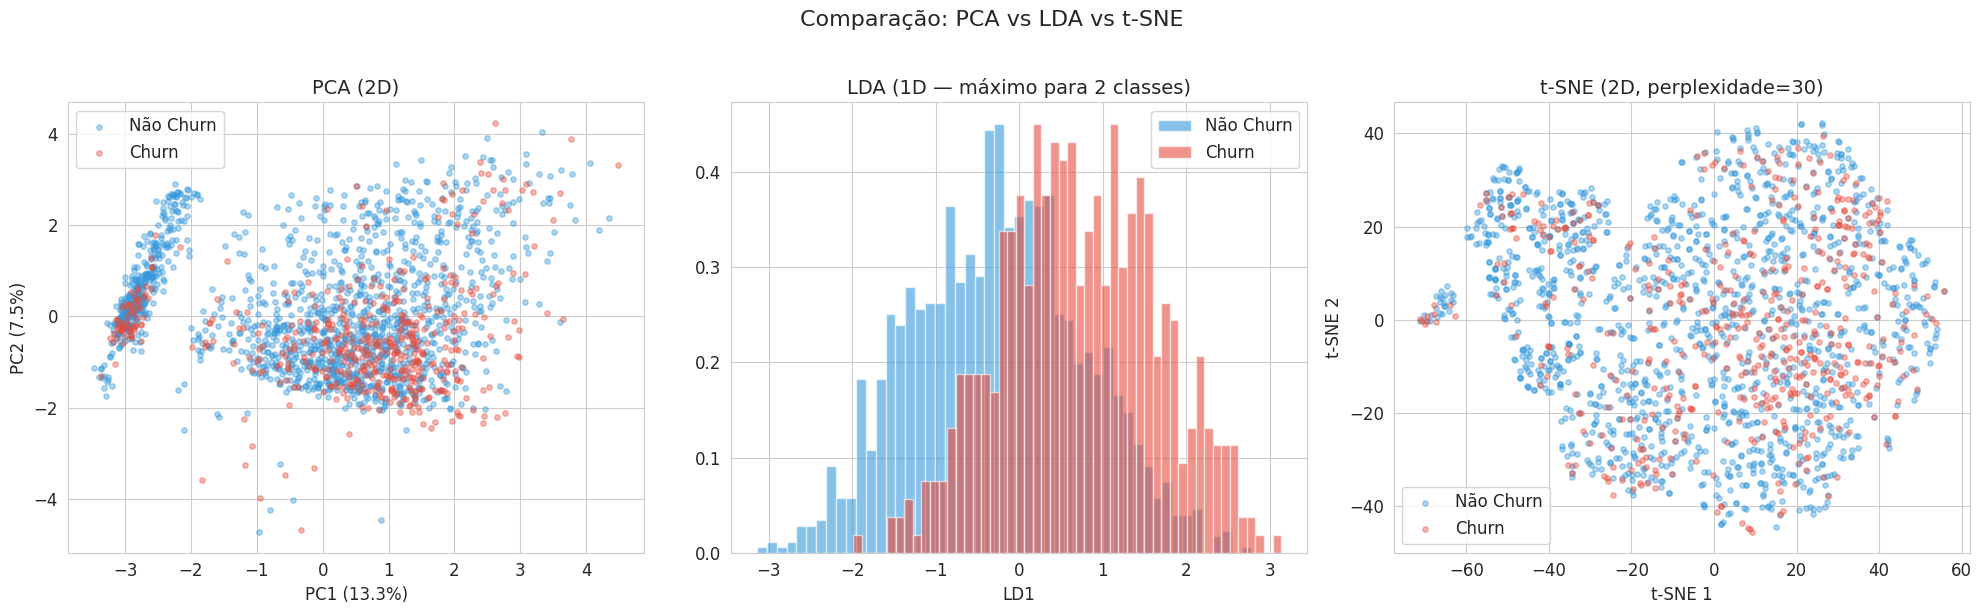

In [ ]:
# Comparação das 3 técnicas lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# PCA 2D
for cls in [0, 1]:
    mask = y == cls
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=colors[cls], label=labels[cls], alpha=0.4, s=15)
axes[0].set_title('PCA (2D)', fontsize=14)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# LDA (1D → histograma)
for cls in [0, 1]:
    mask = y == cls
    axes[1].hist(X_lda[mask], bins=50, alpha=0.6, color=colors[cls],
                 label=labels[cls], density=True)
axes[1].set_title('LDA (1D — máximo para 2 classes)', fontsize=14)
axes[1].set_xlabel('LD1')
axes[1].legend()

# t-SNE 2D (com perplexidade 30)
tsne_best = TSNE(n_components=2, perplexity=30, random_state=42,
                  max_iter=1000, learning_rate='auto', init='pca')
X_tsne_best = tsne_best.fit_transform(X_scaled)

for cls in [0, 1]:
    mask = y == cls
    axes[2].scatter(X_tsne_best[mask, 0], X_tsne_best[mask, 1],
                    c=colors[cls], label=labels[cls], alpha=0.4, s=15)
axes[2].set_title('t-SNE (2D, perplexidade=30)', fontsize=14)
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')
axes[2].legend()

plt.suptitle('Comparação: PCA vs LDA vs t-SNE', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


---
## 11. Impacto Prático: Avaliação com Modelo de Classificação

Vamos medir o impacto real da redução de dimensionalidade na performance de um modelo **Random Forest** aplicado ao problema de churn.


In [ ]:
# Comparar performance: todas features vs PCA vs LDA
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

results = {}

# 1. Todas as features (após filtragem)
rf_full = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X_train, y_train)
y_pred_full = rf_full.predict(X_test)
results['Todas Features'] = {
    'Acurácia': accuracy_score(y_test, y_pred_full),
    'N_Features': X_train.shape[1]
}

# 2. PCA com 90% variância
pca_model = PCA(n_components=0.90)
X_train_pca = pca_model.fit_transform(X_train)
X_test_pca = pca_model.transform(X_test)
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)
results['PCA (90%)'] = {
    'Acurácia': accuracy_score(y_test, y_pred_pca),
    'N_Features': X_train_pca.shape[1]
}

# 3. PCA com 95% variância
pca_model_95 = PCA(n_components=0.95)
X_train_pca95 = pca_model_95.fit_transform(X_train)
X_test_pca95 = pca_model_95.transform(X_test)
rf_pca95 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca95.fit(X_train_pca95, y_train)
y_pred_pca95 = rf_pca95.predict(X_test_pca95)
results['PCA (95%)'] = {
    'Acurácia': accuracy_score(y_test, y_pred_pca95),
    'N_Features': X_train_pca95.shape[1]
}

# 4. LDA
lda_model = LDA(n_components=1)
X_train_lda = lda_model.fit_transform(X_train, y_train)
X_test_lda = lda_model.transform(X_test)
rf_lda = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_lda.fit(X_train_lda, y_train)
y_pred_lda = rf_lda.predict(X_test_lda)
results['LDA (1 comp)'] = {
    'Acurácia': accuracy_score(y_test, y_pred_lda),
    'N_Features': X_train_lda.shape[1]
}

# Tabela comparativa
results_df = pd.DataFrame(results).T
results_df['Acurácia'] = results_df['Acurácia'].apply(lambda x: f"{x:.4f}")
results_df['N_Features'] = results_df['N_Features'].astype(int)
results_df['Redução'] = [
    f"0%",
    f"{(1 - X_train_pca.shape[1]/X_train.shape[1])*100:.0f}%",
    f"{(1 - X_train_pca95.shape[1]/X_train.shape[1])*100:.0f}%",
    f"{(1 - 1/X_train.shape[1])*100:.0f}%"
]

print("=" * 70)
print("COMPARAÇÃO DE PERFORMANCE COM RANDOM FOREST")
print("=" * 70)
print(results_df.to_string())


COMPARAÇÃO DE PERFORMANCE COM RANDOM FOREST
               Acurácia  N_Features Redução
Todas Features   0.7650          23      0%
PCA (90%)        0.7450          18     22%
PCA (95%)        0.7525          19     17%
LDA (1 comp)     0.6625           1     96%


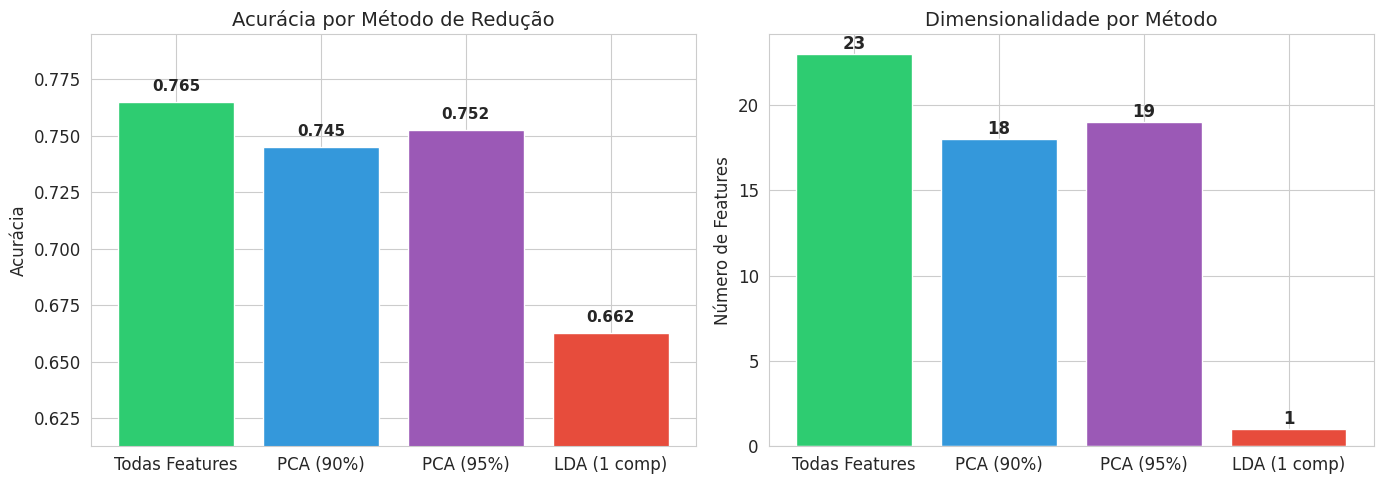

In [ ]:
# Visualização do comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = list(results.keys())
accuracies = [float(results[m]['Acurácia']) for m in methods]
n_feats = [results[m]['N_Features'] for m in methods]

# Acurácia
bars1 = axes[0].bar(methods, accuracies, color=['#2ecc71', '#3498db', '#9b59b6', '#e74c3c'])
axes[0].set_ylabel('Acurácia')
axes[0].set_title('Acurácia por Método de Redução')
axes[0].set_ylim(min(accuracies) - 0.05, max(accuracies) + 0.03)
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', fontweight='bold', fontsize=11)

# Número de features
bars2 = axes[1].bar(methods, n_feats, color=['#2ecc71', '#3498db', '#9b59b6', '#e74c3c'])
axes[1].set_ylabel('Número de Features')
axes[1].set_title('Dimensionalidade por Método')
for bar, nf in zip(bars2, n_feats):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 str(nf), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


---
## 12. Resumo e Guia de Decisão

### Quando usar cada técnica?

| Situação | Técnica Recomendada |
|----------|-------------------|
| Dataset com muitos missings | Análise e remoção de colunas (> 50%) |
| Features constantes ou quase-constantes | Remoção por baixa variabilidade |
| Features redundantes / correlacionadas | Análise de multicolinearidade + VIF |
| Redução geral sem labels | **PCA** |
| Redução para classificação com labels | **LDA** |
| Visualização exploratória em 2D | **t-SNE** |
| Dados com relações não-lineares | t-SNE (visualização) ou Autoencoders (redução) |

### Fluxo recomendado para projetos de Data Science

```
Dados Brutos
    │
    ▼
1. Remover colunas com >50% missing
    │
    ▼
2. Remover features constantes/quase-constantes
    │
    ▼
3. Tratar multicolinearidade (correlação + VIF)
    │
    ▼
4. Encoding de categóricas
    │
    ▼
5. Padronização (StandardScaler)
    │
    ▼
6. PCA/LDA conforme o objetivo
    │
    ▼
7. Modelo de ML
```

### Pontos-chave para lembrar

- **PCA** é não-supervisionado e preserva variância → bom para compressão geral
- **LDA** é supervisionado e preserva separabilidade → bom para classificação
- **t-SNE** é para visualização apenas → nunca use para treinar modelos
- A redução de dimensionalidade é um **trade-off** entre informação e simplicidade
- Sempre valide o impacto no modelo final com métricas reais


---

### Exercícios Propostos

1. **Exploratório**: Altere o limiar de multicolinearidade de 0.85 para 0.70 e observe quantas features adicionais são removidas. Como isso impacta a performance?

2. **PCA**: Experimente usar PCA com variância acumulada de 80% e compare com 95%. Qual é o ponto de "retorno marginal decrescente"?

3. **t-SNE**: Execute o t-SNE com `perplexity=10` e `perplexity=100`. Documente as diferenças visuais e explique o porquê.

4. **Desafio**: Implemente o cálculo do VIF para TODAS as features (incluindo dummies) e identifique quais dummies one-hot são problemáticas. Por quê?

5. **Negócio**: Você é o Data Scientist de uma telecom. Seu gestor pede um relatório de 1 página explicando por que reduzir de 30 para 8 features melhora (ou não) a previsão de churn. Como você argumenta?

---
*Material preparado para a disciplina de Feature Engineering — FIAP*
